# DataLake - Jogos Olímpicos
- Aluno: Pedro Yutaro Mont Morency Nakamura
- Disciplina: Ciência de Dados
- Data: Março de 2026

## Descrição da Atividade:
Este notebook utiliza dados históricos das Olimpíadas (1896–2022) e dados
dos Jogos Olímpicos de Paris 2024 para consolidar o total de medalhas
por país, por meio da arquitetura por zonas.

Os dados foram obtidos das seguintes fontes:

- Base dos Dados – Histórico das Olimpíadas
- Kaggle – Paris 2024 Olympic Summer Games

## 1. Importações e Configurações:

Importação de módulos padrão

In [28]:
import sys
from pathlib import Path
from typing import Literal

Configuração de Path:

In [29]:
root = Path().absolute().parent.parent
sys.path.append(str(root))

Importação de módulos locais:

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src import CatalogManager
from src.pipeline_utils import save_and_catalog

### 1.1. Carregando Dados

In [31]:
catalog = CatalogManager()

In [32]:
src_integrated_athletes = '../../silver/joins/integrated_athletes_results.parquet'

df = pd.read_parquet(src_integrated_athletes)

In [33]:
df.head()

,edition_id,country_noc,sport,event,athlete_name,athlete_id,sex,medal_type,year,season,edition
0,5,ANZ,Athletics,"100 metres, Men",Ernest Hutcheon,64710,Male,NaN,1908,Summer,1908 Summer Olympics
1,5,ANZ,Athletics,"400 metres, Men",Henry Murray,64756,Male,NaN,1908,Summer,1908 Summer Olympics
2,5,ANZ,Athletics,"800 metres, Men",Harvey Sutton,64808,Male,NaN,1908,Summer,1908 Summer Olympics
3,5,ANZ,Athletics,"800 metres, Men",Guy Haskins,922519,Male,NaN,1908,Summer,1908 Summer Olympics
4,5,ANZ,Athletics,"800 metres, Men",Joseph Lynch,64735,Male,NaN,1908,Summer,1908 Summer Olympics


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 319149 entries, 0 to 319148
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   edition_id    319149 non-null  int64
 1   country_noc   319149 non-null  str  
 2   sport         319149 non-null  str  
 3   event         319149 non-null  str  
 4   athlete_name  319149 non-null  str  
 5   athlete_id    319149 non-null  int64
 6   sex           319142 non-null  str  
 7   medal_type    47002 non-null   str  
 8   year          319149 non-null  int64
 9   season        319149 non-null  str  
 10  edition       319149 non-null  str  
dtypes: int64(3), str(8)
memory usage: 51.1 MB


In [35]:
df.isnull().sum()

edition_id           0
country_noc          0
sport                0
event                0
athlete_name         0
athlete_id           0
sex                  7
medal_type      272147
year                 0
season               0
edition              0
dtype: int64

In [36]:
df.medal_type.value_counts()

medal_type
gold      15824
bronze    15746
silver    15432
Name: count, dtype: int64

## 2. Processando Análise de Resultados por Gênero

In [71]:
df.sex.value_counts()

sex
Male      228534
Female     90608
Name: count, dtype: int64

In [73]:
print(df['year'].isna().sum())

0


In [ ]:
print(df['sex'].isna().sum())

7


In [87]:
df = df.dropna(subset=['sex'])
gender_evolution = df.groupby(['year', 'sex']).size().unstack(fill_value=0)

gender_evolution['total'] = gender_evolution['Female'] + gender_evolution['Male']
gender_evolution['% Female'] = (gender_evolution['Female'] / gender_evolution['total']) * 100
gender_evolution['% Male'] = (gender_evolution['Male'] / gender_evolution['total']) * 100

In [88]:
gender_evolution.head()

sex,Female,Male,total,% Female,% Male
year,,,,,
1896,2,617,619,0.323102,99.676898
1900,71,4261,4332,1.638966,98.361034
1904,17,3070,3087,0.550696,99.449304
1906,0,23,23,0.000000,100.000000
1908,58,3979,4037,1.436710,98.563290


In [89]:
save_and_catalog(
    df=gender_evolution.reset_index(),
    filename="olympic_gender_evolution",
    layer="gold",
    output_path="./",
    description="Evolução histórica da participação por gênero (1896-2024)",
    src=f"{src_integrated_athletes}",
    file_format=".csv",
    catalog_manager=catalog,
    observations='Esse Dado foi gerado na camada gold, na análise de Gêneros, no contexto do percentual de participação histórica de gêneros.',
)

✅ Dataset olympic_gender_evolution processado com sucesso na camada gold.


## 3. Geração de Gráficos e Dados Visuais:

### 3.1 Função geradora de gráficos 

In [90]:
def plot_gender_evolution(
    df: pd.DataFrame,
    title: str,
    filename: str,
    x,
    y: str,
    savefig: bool,
    xlabel: str,
    ylabel: str,
    mark_color: str,
    line_color: str,
    line_label: str,
    figsize: tuple[int, int] = (12, 6),
    img_format: Literal['.png', 'jpeg'] = '.png'
):
  plt.figure(figsize=figsize)

  sns.lineplot(
    data=df,
    x=x,
    y=y,
    marker='o',
    color=mark_color,
  )

  plt.axhline(50, color=line_color, linestyle='--', label=line_label)

  plt.title(title, fontsize=14)
  plt.ylabel(ylabel)
  plt.xlabel(xlabel)
  plt.legend()
  plt.grid(True, alpha=0.3)

  filestr = f"{filename}.{img_format}"
  if savefig:
    plt.savefig(filestr)

  plt.show()


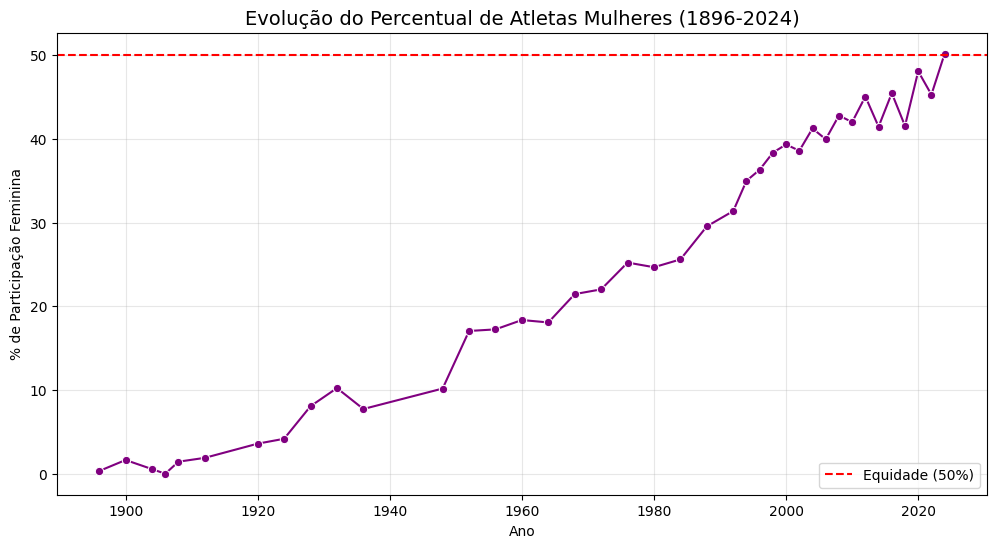

In [95]:
plot_gender_evolution(
  df=gender_evolution,
  savefig=True,
  filename='gender_female_evolution',
  line_color='red',
  mark_color='purple',
  line_label='Equidade (50%)',
  title='Evolução do Percentual de Atletas Mulheres (1896-2024)',
  y='% Female',
  x=gender_evolution.index,
  xlabel='Ano',
  ylabel='% de Participação Feminina'
)

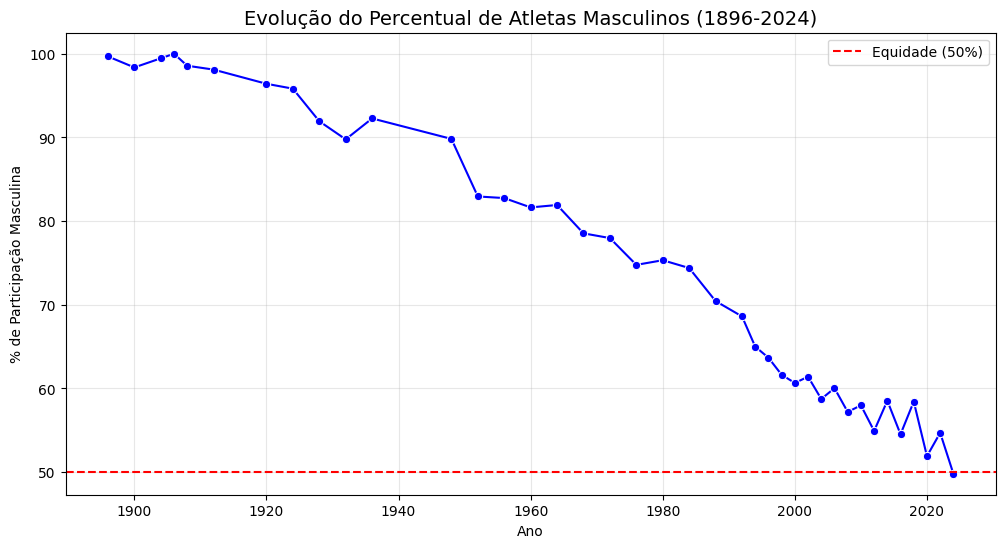

In [99]:
plot_gender_evolution(
  df=gender_evolution,
  savefig=True,
  filename='gender_male_evolution',
  line_color='red',
  mark_color='blue',
  line_label='Equidade (50%)',
  title='Evolução do Percentual de Atletas Masculinos (1896-2024)',
  y='% Male',
  x=gender_evolution.index,
  xlabel='Ano',
  ylabel='% de Participação Masculina'
)

In [ ]:
def plot_gender_comparison(df, savefig=False, filename='comparacao_genero'):
    plt.figure(figsize=(12, 7))

    # Plotando a participação Masculina
    sns.lineplot(data=df, x=df.index, y='% Male', marker='o', 
                 color='royalblue', label='Participação Masculina', linewidth=2)
    
    # Plotando a participação Feminina
    sns.lineplot(data=df, x=df.index, y='% Female', marker='o', 
                 color='crimson', label='Participação Feminina', linewidth=2)

    # Linha de Equidade (50%)
    plt.axhline(50, color='green', linestyle='--', alpha=0.6, label='Equidade (50%)')

    # Customização
    plt.title('Participação Masculina vs. Feminina (1896-2024)', fontsize=15, pad=20)
    plt.ylabel('Percentual de Participação (%)', fontsize=12)
    plt.xlabel('Ano das Olimpíadas', fontsize=12)
    plt.ylim(-5, 105) # Garante que a escala vá de 0 a 100
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    if savefig:
        plt.savefig(f"{filename}.png", dpi=300)
    
    plt.show()

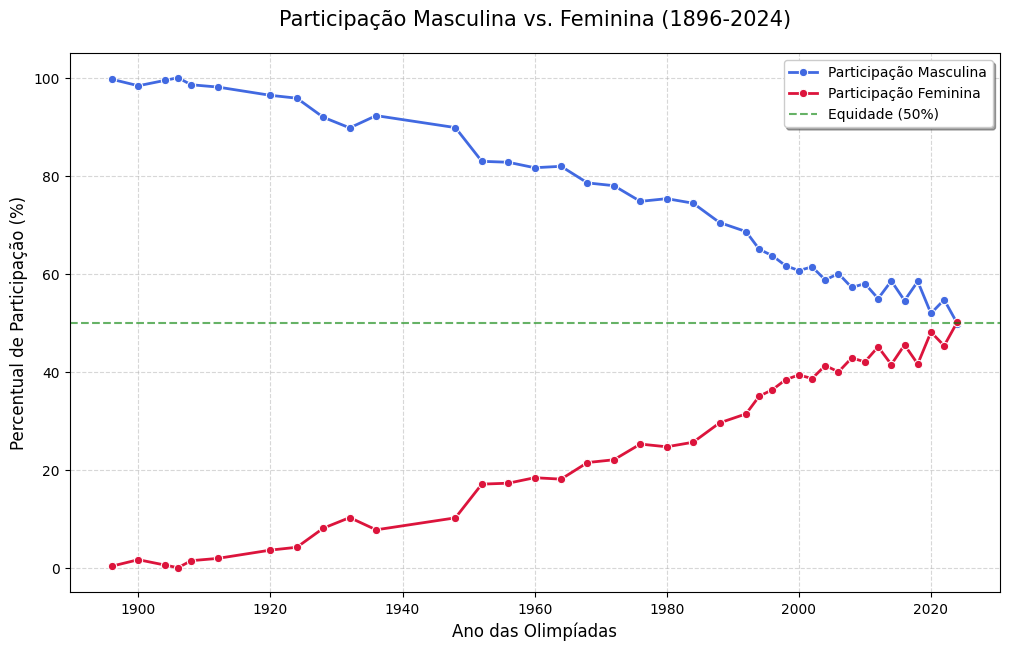

In [100]:
plot_gender_comparison(df=gender_evolution, filename='male_X_female_analysis', savefig=True)